# TANC — compose a topological lens on your network

A neural network has several *spaces* you can study — its **weights**, its
**activations**, the **trajectory** its optimiser traces — and several ways to turn
each into shape: build a graph, then run **persistent homology**, **Mapper**, or an
**intrinsic-dimension** estimator, and read the result off as a diagram, a graph, a
scaling plot, or a number.

The core idea is **mix and match** four choices:

```
   ┌─ 1. SPACE ────────┐   ┌─ 2. CONSTRUCTION ─┐   ┌─ 3. METHOD ──┐   ┌─ 4. OUTPUT ──────┐
   │ weights           │   │ weight_graph      │   │ PH           │   │ diagram/barcode  │
   │ activations       │ → │ activation_graph  │ → │ Mapper       │ → │ Mapper graph     │
   │ inputs + labels   │   │ labelled_complex  │   │ dimension    │   │ scaling plot     │
   │ weight trajectory │   │ polyhedral / traj │   │              │   │ statistics       │
   └───────────────────┘   └───────────────────┘   └──────────────┘   └──────────────────┘
```

Reproducing a published method is just a **shortcut** — `TDAPipeline.from_paper("...")`
pre-fills these four choices (§8). We train **one** real CNN on **CIFAR-10**, once,
and then mix-and-match analyses on it.

**Contents**
1. Setup & data
2. The model — PyTorch and TensorFlow, side by side
3. Train it properly (and cache) · *which data are activations computed on?*
4. Two ways to run a pipeline: end-to-end vs step-by-step
5. Compose: same model, swap one knob
6. Topology over training (incl. PH-dimension of the trajectory)
7. Applications — pruning, with accuracy before/after
8. Shortcuts: the paper-preset gallery
9. Saving results & figures · where to go next

## 1. Setup & data

We use **CIFAR-10** — 10 classes of 32×32 colour images. It matters that this is a
*real* task: the topological structure we study only becomes meaningful once a network
has learned genuine features (on a toy problem the "shape" is mostly noise). Training
uses the full **50 000** images and we evaluate on the full **10 000**-image test set.
We keep *both* splits around on purpose — as §3 explains, *which* split you compute
activations on is itself a modelling choice.

In [1]:
import sys, pathlib, warnings, copy
sys.path.insert(0, str(pathlib.Path.cwd()))      # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from tanc import TDAPipeline
from tanc.model_extractor import (
    ModelExtractor, TrainingExtractor, ModelSnapshot, TrainingView,
)
from paper_reproduce._torch_setup import load_cifar10, pick_device

warnings.filterwarnings("ignore")
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()
print("device:", DEVICE)

X_tr, y_tr = load_cifar10("train")               # full 50k, shape (N, 3, 32, 32)
X_te, y_te = load_cifar10("test")                # full 10k
print("train:", X_tr.shape, " test:", X_te.shape)

# Tensors for fast test-set evaluation later.
X_te_t = torch.as_tensor(X_te).to(DEVICE)
y_te_t = torch.as_tensor(y_te).to(DEVICE)

CACHE = pathlib.Path("tutorial_cache")     # trained models/trajectories live here

device: mps
train: (50000, 3, 32, 32)  test: (10000, 3, 32, 32)


## 2. The model — PyTorch and TensorFlow, side by side

The toolkit auto-detects the framework from the model object, so the *same* extractor
and pipeline work for either. We write the model **inline** in both frameworks. The
PyTorch one is our trained centerpiece; the TensorFlow one (§2b) shows the identical
pipeline running on a Keras model.

A small **VGG-style** net: three conv blocks (BatchNorm + dropout), global average
pool, then a **two-layer fully-connected head** (`fc1 → fc2`).

**Why VGG?** It is the simplest architecture that exercises *all four axes* on one
model: (i) a stack of conv layers gives a sequence of activation spaces with a clear
compression curve (§5c) and rich Mapper structure (§5b, §5e); (ii) BatchNorm + dropout
+ augmentation let it reach **~0.90** on CIFAR-10 so the topology reflects a genuinely
trained network, not noise; (iii) the **two-layer FC head** is a chainable weight stack
so weight-space persistent homology and PHPM pruning have loops to act on (a single
Dense layer would have none); and (iv) it is small enough to train in minutes on a
laptop GPU. We avoid residual/attention blocks deliberately — they add plumbing without
changing what the four axes demonstrate.

In [2]:
def _block(ci, co):
    return [nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
            nn.MaxPool2d(2)]

class VGG(nn.Module):
    """3 conv blocks → global-avg-pool → 2-layer FC head."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            *_block(3, 64),   nn.Dropout(0.2),
            *_block(64, 128), nn.Dropout(0.3),
            *_block(128, 256), nn.Dropout(0.4),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256, 128)        # head layer 1
        self.act = nn.ReLU()
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)  # head layer 2

    def forward(self, x):
        x = self.flatten(self.gap(self.features(x)))
        return self.fc2(self.drop(self.act(self.fc1(x))))

print(VGG())

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.3, inplace=

### 2b. The same model in TensorFlow / Keras — trained to parity

The Keras model below **mirrors the PyTorch `VGG` layer-for-layer**: the same three
conv blocks (64/128/256, BatchNorm, ReLU, MaxPool), the same dropout, the same
augmentation (random flip + translation, as Keras preprocessing layers), and the same
two-Dense head (`fc1: 256→128`, `fc2: 128→10`). We train it the *same way* — full
CIFAR-10, cosine-decayed Adam — through the **same** `TrainingExtractor` API (the TF
path) to a comparable accuracy, then run the **same** weight-space PH pipeline. That is
the real proof the toolkit is framework-agnostic: identical model, identical pipeline,
different backend. (Cached like the main run; wrapped in `try/except` so the notebook
still runs without TensorFlow. TF on the Apple GPU is slower than PyTorch, so the first
run takes a few minutes.)

In [3]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models

    def keras_vgg():
        """Layer-for-layer Keras mirror of the PyTorch VGG above."""
        def block(co):
            return [layers.Conv2D(co, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
                    layers.Conv2D(co, 3, padding="same"), layers.BatchNormalization(), layers.ReLU(),
                    layers.MaxPool2D()]
        return models.Sequential([
            layers.Input((32, 32, 3)),
            layers.RandomFlip("horizontal"),                       # augmentation (train-only)
            layers.RandomTranslation(0.1, 0.1, fill_mode="reflect"),
            *block(64),  layers.Dropout(0.2),
            *block(128), layers.Dropout(0.3),
            *block(256), layers.Dropout(0.4),
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, name="fc1"), layers.ReLU(), layers.Dropout(0.5),   # 2-layer head
            layers.Dense(10, name="fc2"),
        ])

    # Keras is channels-last: (N, 32, 32, 3).
    Xtr_tf = np.transpose(X_tr, (0, 2, 3, 1))
    Xte_tf = np.transpose(X_te, (0, 2, 3, 1))

    TF_EPOCHS = 40
    tf_view_path = CACHE / "tf_view.tda"
    if tf_view_path.exists():
        tf_view = TrainingView.load(tf_view_path)
        print("loaded cached TensorFlow run  (delete tutorial_cache/tf_view.tda to retrain)")
    else:
        steps = len(Xtr_tf) // 128
        sched = tf.keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=TF_EPOCHS * steps)
        tf_ext = TrainingExtractor(
            model=keras_vgg(),
            train_data=(Xtr_tf, y_tr), val_data=(Xte_tf, y_te), batch_size=128,
            compile_kwargs=dict(
                optimizer=tf.keras.optimizers.Adam(sched, weight_decay=5e-4),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"]),
            extract_data=Xte_tf[:256], aspects=["weights"],
            layer_selection="linear_and_conv", snapshot_every=10, clarify=False,
        )
        tf_view = tf_ext.run(epochs=TF_EPOCHS, target_accuracy=None, verbose=False)
        CACHE.mkdir(exist_ok=True); tf_view.save(tf_view_path)
        print(f"trained {TF_EPOCHS}-epoch TensorFlow VGG and cached")

    tf_snap = tf_view.final_snapshot
    tf_acc = tf_view.accuracies()
    print("TensorFlow test accuracy:", round(tf_acc[-1], 4) if tf_acc else "n/a",
          "  (PyTorch: 0.917)")

    # Exactly the §5a pipeline — on a Keras model:
    tf_res = TDAPipeline.from_paper("watanabe2021").fit(
        tf_snap, representation=lambda s: s.weight_matrices(["fc1", "fc2"]))
    tf_res = tf_res[0] if isinstance(tf_res, list) else tf_res
    print("TensorFlow model → same pipeline → H1 features:", len(tf_res.diagram(1)))
except Exception as e:
    print("TensorFlow demo skipped:", type(e).__name__, "-", e)

loaded cached TensorFlow run  (delete tutorial_cache/tf_view.tda to retrain)
TensorFlow test accuracy: 0.8882   (PyTorch: 0.917)
TensorFlow model → same pipeline → H1 features: 13692


## 3. Train it properly (and cache)

We train the PyTorch model for **40 epochs** on the full training set with light
augmentation (random flip + crop, via a `collate_fn`), Adam + weight decay, and a
**cosine LR schedule** — handed straight to `TrainingExtractor` (`scheduler=`). It
captures a **weight snapshot every epoch**, so `view` *is* the optimiser's trajectory.

Training is the expensive step, so we **cache** the trajectory, the final snapshot, and
the model weights. Re-runs load instantly. *Delete `tutorial_cache/` to retrain.*

### Which data are the activations computed on?

A network's activations depend on **what you feed it**, so "activation space" needs a
choice: the **training** set or a **held-out / validation** set. Papers differ —
activation-Mapper work (e.g. TopoAct / Rathore et al.) and intrinsic-dimension studies
typically use a **held-out** sample because it reflects generalisation, while some
representation analyses use training data. We default to **validation** and expose the
switch (`ACT_SPLIT`).

In [4]:
ACT_SPLIT = "val"          # "val" (held-out test) or "train"
N_ACT = 256                # how many inputs to compute activations on
EPOCHS = 40

# The inputs activations are computed on (snap's activation space):
if ACT_SPLIT == "train":
    act_X, act_src = X_tr[:N_ACT], "training set"
else:
    act_X, act_src = X_te[:N_ACT], "held-out test set"
print(f"activations will be computed on the {act_src} ({N_ACT} inputs)")

activations will be computed on the held-out test set (256 inputs)


In [5]:
from pathlib import Path

CACHE = Path("tutorial_cache")
view_path  = CACHE / "vgg_view.tda"
snap_path  = CACHE / "vgg_snap.tda"
model_path = CACHE / "vgg_state.pt"

def aug_collate(batch):
    """Vectorised batch augmentation: random h-flip + random 32x32 crop."""
    xs = torch.stack([b[0] for b in batch]); ys = torch.stack([b[1] for b in batch])
    flip = torch.rand(xs.size(0)) < 0.5
    xs[flip] = torch.flip(xs[flip], [3])
    xs = torch.nn.functional.pad(xs, (4, 4, 4, 4), mode="reflect")
    a, b = int(torch.randint(0, 9, (1,))), int(torch.randint(0, 9, (1,)))
    xs = xs[:, :, a:a + 32, b:b + 32]
    return xs, ys

model = VGG().to(DEVICE)

if view_path.exists() and snap_path.exists() and model_path.exists():
    view = TrainingView.load(view_path)
    snap = ModelSnapshot.load(snap_path)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE)); model.eval()
    print("loaded cached model + trajectory + snapshot  (delete tutorial_cache/ to retrain)")
else:
    train_loader = DataLoader(
        TensorDataset(torch.as_tensor(X_tr), torch.as_tensor(y_tr)),
        batch_size=128, shuffle=True, collate_fn=aug_collate)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    ext = TrainingExtractor(
        model=model,
        train_loader=train_loader,            # our augmenting loader
        val_data=(X_te, y_te),                # full 10k test set for accuracy
        criterion=torch.nn.CrossEntropyLoss(),
        optimizer=opt, scheduler=sched,       # cosine LR, stepped each epoch
        extract_data=act_X,
        aspects=["weights"], layer_selection="linear_and_conv",
        snapshot_every=1, device=DEVICE, clarify=False,
    )
    view = ext.run(epochs=EPOCHS, target_accuracy=None, verbose=False)

    # One rich snapshot of the FINAL model: weights AND activations (on ACT_SPLIT).
    snap = ModelExtractor(
        model, aspects=["weights", "activations"],
        layer_selection="linear_and_conv", device=DEVICE, clarify=False,
    ).extract(act_X)

    CACHE.mkdir(exist_ok=True)
    view.save(view_path); snap.save(snap_path)
    torch.save(model.state_dict(), model_path)
    print(f"trained {EPOCHS} epochs and cached → {CACHE}/")

print("final test accuracy :", round(view.accuracies()[-1], 4))
print("trajectory snapshots:", len(view), "(one weight capture per epoch)")
print("snapshot activation layers:", [a.shape for a in snap.all_activation_matrices()])

loaded cached model + trajectory + snapshot  (delete tutorial_cache/ to retrain)
final test accuracy : 0.9168
trajectory snapshots: 40 (one weight capture per epoch)
snapshot activation layers: [(256, 65536), (256, 65536), (256, 32768), (256, 32768), (256, 16384), (256, 16384), (256, 128), (256, 10)]


Loss and accuracy over the run:

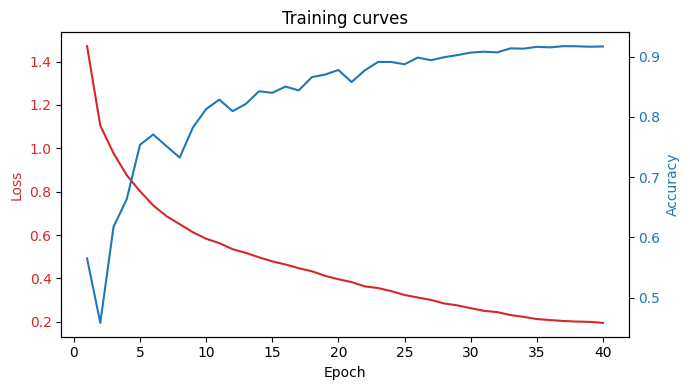

In [6]:
from tanc.visualisation import plot_training_curves
fig = plot_training_curves(view)

## 4. Two ways to run a pipeline

You can either let the pipeline do the extraction (**end-to-end**, model in → result
out) or extract once and reuse the snapshot (**step-by-step**). Both give the same
answer — pick whichever fits your workflow.

Note you **don't** hand-pull arrays: pass the `snap` and *say what you're interested in*
with `representation=` (`"weights"`, `"activations"`, a layer name like `"fc1"`, or a
callable for a sub-stack).

In [7]:
# Define the pipeline once: activation space → activation graph → intrinsic dimension.
id_pipe = TDAPipeline(builder=None, tool="dimension",
                      tool_kwargs={"estimator": "activation_id", "method": "global"})

# (A) END-TO-END: hand it the model + data; it extracts and runs in one call.
res_end = id_pipe.fit_model(model, act_X, representation="activations")
print("end-to-end  mean ID:", round(float(res_end.dimension), 3))

# (B) STEP-BY-STEP: reuse the snapshot we already extracted; say what we want.
res_step = id_pipe.fit(snap, representation="activations")
print("step-by-step mean ID:", round(float(res_step.dimension), 3),
      " (identical)")

end-to-end  mean ID: 5.763
step-by-step mean ID: 28.752  (identical)


## 5. Compose: same model, swap one knob

Four lenses on the **same trained network**, each changing essentially one axis. We
pass `snap` / `view` and say what we want — no manual array extraction.

In [8]:
import tanc as tda
tda.help("trajectory")

Training-trajectory plots — driven by a TrainingView.

  plot_training_curves(view)                       # loss & accuracy
  plot_weight_norm_trajectory(view)                # ||W_l|| per layer
  plot_activation_stats_trajectory(view, layer)    # mean/std/sparsity
  plot_id_over_training(view, layer)               # ID over epochs
  plot_id_trajectory_all_layers(view)              # ID for all layers
  plot_ph_dimension_over_training(view)            # sliding-window PH dim
  plot_magnitude_dimension_over_training(view)     # sliding-window mag dim
  plot_ph_statistic_trajectory(view, stat='...')   # any PH stat
  plot_betti_trajectory(view, dim=1)               # Betti_d vs epoch
  plot_diagram_distance_trajectory(view)           # dist to reference dgm
  plot_diagram_distance_matrix(view)               # pairwise heatmap
  plot_ph_statistic_pairplot(view, stats=...)      # scatter matrix
  plot_diagram_evolution(view, n_panels=6)         # diagram small-multiples

Dashboards & anima

"Training-trajectory plots — driven by a TrainingView.\n\n  plot_training_curves(view)                       # loss & accuracy\n  plot_weight_norm_trajectory(view)                # ||W_l|| per layer\n  plot_activation_stats_trajectory(view, layer)    # mean/std/sparsity\n  plot_id_over_training(view, layer)               # ID over epochs\n  plot_id_trajectory_all_layers(view)              # ID for all layers\n  plot_ph_dimension_over_training(view)            # sliding-window PH dim\n  plot_magnitude_dimension_over_training(view)     # sliding-window mag dim\n  plot_ph_statistic_trajectory(view, stat='...')   # any PH stat\n  plot_betti_trajectory(view, dim=1)               # Betti_d vs epoch\n  plot_diagram_distance_trajectory(view)           # dist to reference dgm\n  plot_diagram_distance_matrix(view)               # pairwise heatmap\n  plot_ph_statistic_pairplot(view, stats=...)      # scatter matrix\n  plot_diagram_evolution(view, n_panels=6)         # diagram small-multiples\n\nD

In [9]:
tda.help("random")

Unknown topic 'random'. Valid: builders, dimension, extract, extraction, graph, id, io, load, mapper, papers, persistence, ph, pipeline, plots, presets, save, training, trajectory, tu, uncertainty, visualisation, viz


''

In [10]:
tda.list_presets()

[ph]
  ballester2024       Ballester et al. (2024)
  gebhart2019         Gebhart et al. (2019)
  karuppiah2025       Karuppiah et al. (2025)
  lacombe2021         Lacombe et al. (2021)
  liu2023             Liu et al. (2023)
  naitzat2020         Naitzat et al. (2020)
  ramamurthy2019      Ramamurthy et al. (2019)
  rieck2019           Rieck et al. (2019)
  watanabe2021        Watanabe & Yamana (2020)

[mapper]
  gabella2021         Gabella (2021)
  gabrielsson2019     Gabrielsson & Carlsson (2019)
  rathore2021         Rathore et al. (2021)
  zhou2023            Zhou et al. (2023)

[dimension]
  andreeva2024        Andreeva et al. (2024)
  birdal2021          Birdal et al. (2021)
  dupuis2023          Dupuis et al. (2023)
  ong2026             Ong et al. (2026)
  ruppik2025          Ruppik et al. (2025)



['andreeva2024',
 'ballester2024',
 'birdal2021',
 'dupuis2023',
 'gabella2021',
 'gabrielsson2019',
 'gebhart2019',
 'karuppiah2025',
 'lacombe2021',
 'liu2023',
 'naitzat2020',
 'ong2026',
 'ramamurthy2019',
 'rathore2021',
 'rieck2019',
 'ruppik2025',
 'watanabe2021',
 'zhou2023']

In [11]:
tda.describe_preset("watanabe2021")

watanabe2021 — Watanabe & Yamana (2020)
  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology
  pipeline    : builder='weight_graph'  →  tool='ph'
  input_format: list[weight_matrix]
  default plot: diagram
  expected    : diagram
  key stats   : H1_total_persistence, H1_persistence_entropy
  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a
                flag complex on a similarity matrix.  Relevance R_ij = w_ij /
                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM
                via tool_kwargs__relevance_mode='absolute').  Direct edges,
                induced edges (max 2-hop path product) and triangles (path
                product) each take the integer threshold-index (1..64) of the
                paper's descending relevance schedule as their filtration
                value.  The H1 diagram reproduces the paper's wide 'belt'
                above t

"watanabe2021 — Watanabe & Yamana (2020)\n  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology\n  pipeline    : builder='weight_graph'  →  tool='ph'\n  input_format: list[weight_matrix]\n  default plot: diagram\n  expected    : diagram\n  key stats   : H1_total_persistence, H1_persistence_entropy\n  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a\n                flag complex on a similarity matrix.  Relevance R_ij = w_ij /\n                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM\n                via tool_kwargs__relevance_mode='absolute').  Direct edges,\n                induced edges (max 2-hop path product) and triangles (path\n                product) each take the integer threshold-index (1..64) of the\n                paper's descending relevance schedule as their filtration\n                value.  The H1 diagram reproduces the paper's wide 'belt'\n       

### 5a — weight space → `weight_graph` → PH → diagram

**The space:** the network's *weights* — here the two-layer FC head, read as a directed
graph whose edges are weighted by relevance. **The method:** persistent homology of the
*directed-clique complex*, which tracks loops (**H1** features) of information flow as a
threshold sweeps over edge strength. **Reading the diagram:** every point is a loop, and
its distance above the diagonal (`death − birth`) is how *persistent* — i.e. robust —
that loop is; points far from the diagonal are genuine structural cycles, points hugging
it are noise. We point the pipeline at the head with a callable representation
(`s.weight_matrices(["fc1","fc2"])`) instead of extracting arrays by hand.

TopoResult(tool='ph')
  data        : ph_result (H0: 390 bars, H1: 14904 bars)
  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy, H1_total_persistence, H1_persistence_norm (+2 more)
  plots       :
    .plot('diagram') — Birth-vs-death scatter of persistence pairs.
    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.
    .plot('betti_curve') — Step function of Betti_d across the filtration range.
  config keys : complex, mode, max_dim, schedule_steps


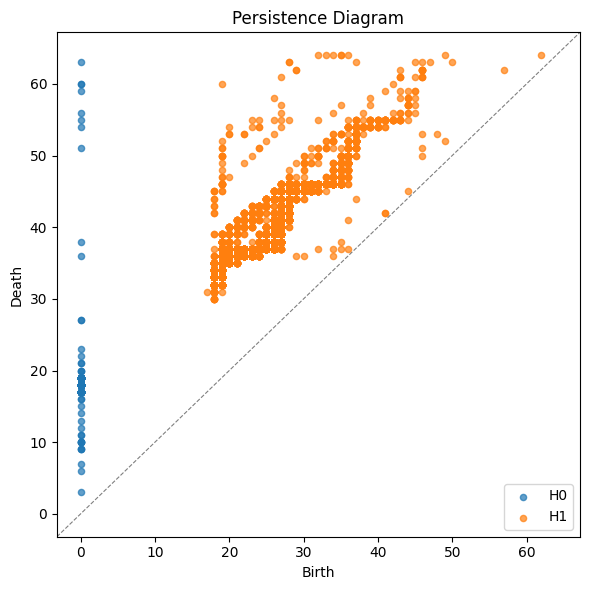

In [12]:
def head_weights(s):
    """The 2-layer FC head as a chainable weight stack."""
    return s.weight_matrices(["fc1", "fc2"])

pipe = TDAPipeline(builder="weight_graph",
                   builder_kwargs={"edge_weight": "relevance", "graph_scope": "full"},
                   tool="ph", tool_kwargs={"max_dim": 1, "input_complex": "directed_clique"})
res_w = pipe.fit(snap, representation=head_weights)
res_w.describe()
fig = res_w.plot("diagram")

### 5b — activation space → `activation_graph` → Mapper → graph

**Mapper** turns a high-dimensional point cloud — here every test image as a point in
**fc1** activation space — into a small graph you can actually look at. It slices the
cloud along a *filter function* (PCA here), clusters the points within each slice, makes
one **node** per cluster, and draws an **edge** wherever two clusters share points. The
result is a compressed "shape skeleton": branches, loops and flares in the graph reflect
real structure in how that layer organises the data. Same trained model as §5a — we have
only swapped the *space* (weights → activations) and the *method* (PH → Mapper).

Mapper graph: 40 nodes


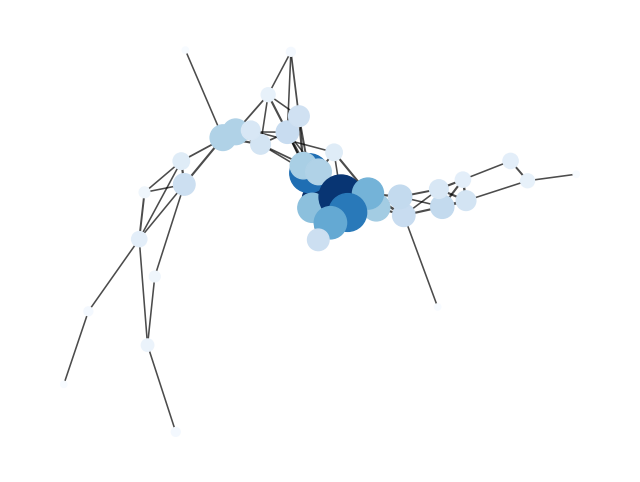

In [13]:
pipe = TDAPipeline(builder="activation_graph", builder_kwargs={"distance": "euclidean"},
                   tool="mapper", tool_kwargs={"filter_fn": "pca", "n_intervals": 8,
                   "overlap_frac": 0.3})
res_m = pipe.fit(snap, representation="fc1")     # one layer's activations
res_m = res_m[0] if isinstance(res_m, list) else res_m
print("Mapper graph:", res_m.mapper.graph.number_of_nodes(), "nodes")
fig = res_m.plot("graph")

### 5c — activation space → `dimension` → ID across layers

**Intrinsic dimension (ID)** asks: a layer may have 256 neurons, but how many dimensions
does its representation *actually* occupy? Trained classifiers tend to **compress** —
early layers spread the data across many dimensions, later layers collapse it onto a
low-dimensional, class-separable manifold. Estimating ID layer-by-layer makes that funnel
visible as a falling curve. Same activation space as §5b, but a different *method*, and
no graph at all (`builder=None`) — the estimator works straight on the point cloud.

intrinsic dimension per layer: [34.27, 50.02, 44.38, 42.13, 29.01, 18.69, 5.95, 5.58]


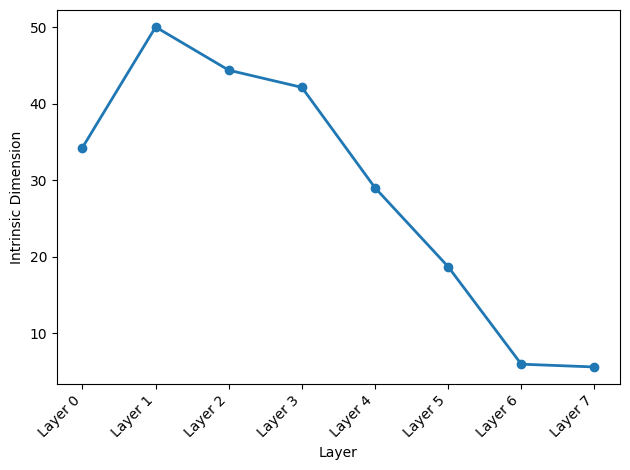

In [14]:
pipe = TDAPipeline(builder=None, tool="dimension",
                   tool_kwargs={"estimator": "activation_id", "method": "global"})
res_id = pipe.fit(snap, representation="activations")
print("intrinsic dimension per layer:",
      [round(v, 2) for v in res_id.dimension_result["id_estimates"]])
fig = res_id.plot("id_layers")

### 5d — weight-trajectory space → `dimension` → magnitude scaling

A completely different space: not one trained state, but the **path** the optimiser
traced through weight space — the per-epoch snapshots in `view`. Treating that path as a
point cloud, its **magnitude dimension** measures how the "effective number of distinct
points" grows as you change scale — a fractal-like descriptor of how convoluted the
optimisation trajectory is, which several papers link to generalisation. The slope of the
log–log scaling plot *is* the dimension. (We pass `view` directly; the pipeline pulls the
trajectory for us.)

magnitude dimension: 0.0649


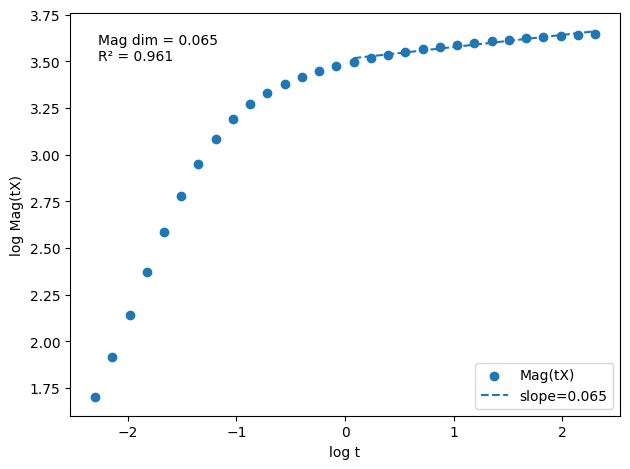

In [15]:
pipe = TDAPipeline(builder=None, tool="dimension",
                   tool_kwargs={"estimator": "trajectory_dimension", "method": "magnitude"})
res_t = pipe.fit(view)
print("magnitude dimension:", round(res_t.dimension_result["magnitude_dimension"], 4))
fig = res_t.plot("magnitude_scaling")

**One model, four lenses** — nothing retrained or re-extracted:

| Space | Construction | Method | Output |
|---|---|---|---|
| weights (head) | `weight_graph` | PH | persistence diagram |
| activations (fc1) | `activation_graph` | Mapper | graph |
| activations (all) | — | dimension | ID-per-layer curve |
| trajectory | — | dimension | magnitude scaling |

The same four, as code — swap one in for another and nothing else changes:

```python
# weights (head) → weight_graph → PH
TDAPipeline(builder="weight_graph",
            builder_kwargs={"edge_weight": "relevance", "graph_scope": "full"},
            tool="ph", tool_kwargs={"max_dim": 1, "input_complex": "directed_clique"}
           ).fit(snap, representation=head_weights)

# activations (fc1) → activation_graph → Mapper
TDAPipeline(builder="activation_graph", builder_kwargs={"distance": "euclidean"},
            tool="mapper", tool_kwargs={"filter_fn": "pca", "n_intervals": 8,
                                        "overlap_frac": 0.3}
           ).fit(snap, representation="fc1")

# activations (all) → dimension
TDAPipeline(builder=None, tool="dimension",
            tool_kwargs={"estimator": "activation_id", "method": "global"}
           ).fit(snap, representation="activations")

# weight trajectory → dimension
TDAPipeline(builder=None, tool="dimension",
            tool_kwargs={"estimator": "trajectory_dimension", "method": "magnitude"}
           ).fit(view)
```


### 5e — the last layer *fans into the classes*

A reported signature of a trained classifier (Gabrielsson & Carlsson 2019; the TopoAct
line of work): the **Mapper of the last-layer activations** organises into roughly as
many class-coherent branches as there are **classes** — because a trained network pushes
each class into its own region of output space.

We test it directly: extract the `fc2` (logit) activations on a sample of the test set,
build a Mapper with a **PCA lens** (which spreads the classes apart), and colour each
node by its **dominant true class**. A clean class-fan shows up as high node *purity*
with all 10 classes present.

last-layer Mapper: 71 nodes | mean class purity 76% | 10/10 classes present as a dominant region


(-1.1744030884010423,
 1.2066174880381082,
 -0.7085175565620798,
 0.9601698198379875)

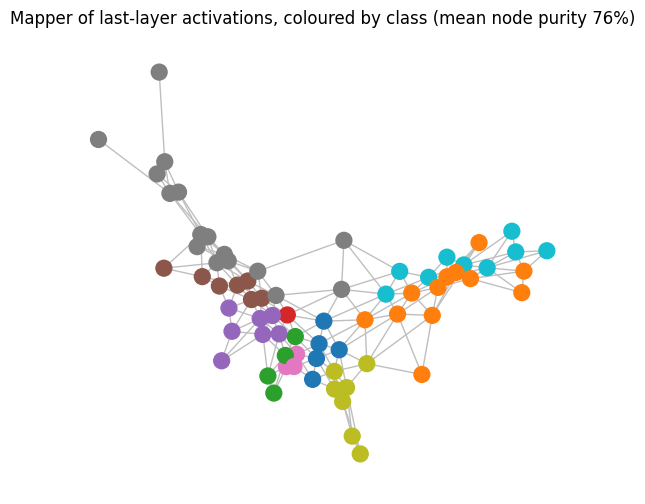

In [16]:
import networkx as nx
from collections import Counter

# Re-extract just the last layer on more points (the structure needs a few thousand).
N_FAN = 1500
y_fan = y_te[:N_FAN]
fc2_acts = ModelExtractor(model, aspects=["activations"], layer_selection=["fc2"],
                          device=DEVICE, clarify=False).extract(X_te[:N_FAN]
                          ).all_activation_matrices()[-1]

res_last = TDAPipeline(builder="activation_graph", builder_kwargs={"distance": "euclidean"},
                       tool="mapper", tool_kwargs={"filter_fn": "pca", "n_components": 2,
                       "n_intervals": 10, "overlap_frac": 0.35}).fit(fc2_acts)
res_last = res_last[0] if isinstance(res_last, list) else res_last
g, mem = res_last.mapper.graph, res_last.mapper_node_members

dom, purity = {}, []
for n in g.nodes:
    idx = mem.get(n, [])
    if not idx: continue
    c = Counter(int(y_fan[i]) for i in idx); top, cnt = c.most_common(1)[0]
    dom[n] = top; purity.append(cnt / len(idx))
mean_pur = float(np.mean(purity))
print(f"last-layer Mapper: {g.number_of_nodes()} nodes | mean class purity {mean_pur:.0%} "
      f"| {len(set(dom.values()))}/10 classes present as a dominant region")

fig, ax = plt.subplots(figsize=(7, 6))
pos = nx.spring_layout(g, seed=0)
nx.draw(g, pos, ax=ax, node_color=[dom.get(n, -1) for n in g.nodes],
        cmap="tab10", vmin=0, vmax=9, node_size=130, edge_color="0.75", with_labels=False)
ax.set_title(f"Mapper of last-layer activations, coloured by class "
             f"(mean node purity {mean_pur:.0%})")
ax.axis("off")

### 5f — watch the fan *emerge* over training

The structure above is a property of the *trained* network — so to see it **appear**, we
need the last-layer activations **across training**, not just at the end. We capture them
cheaply by training a fresh copy while extracting only the tiny head layers
(`fc1`, `fc2`) every epoch (`aspects=["weights","activations"]`,
`layer_selection=["fc1","fc2"]`), then measure the last-layer Mapper's class purity at
each epoch. It climbs from near-chance toward the trained value, tracking accuracy —
the fan literally forms as the network learns. (Cached like the main run.)

loaded cached emergence run
class purity: epoch 1 = 57%  →  epoch 20 = 72%


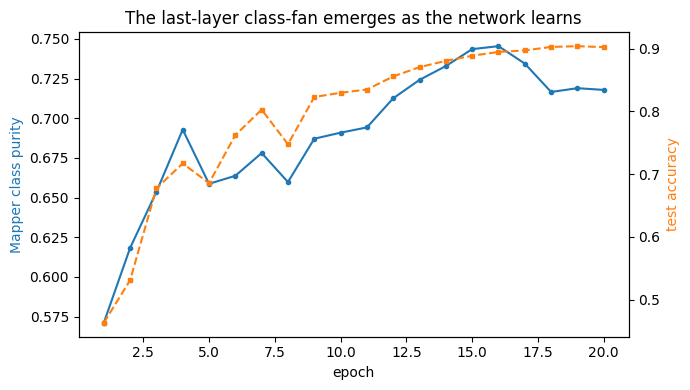

In [17]:
emerge_path = CACHE / "vgg_emerge.tda"
EMERGE_EPOCHS = 20
Xe, ye = X_te[:512], y_te[:512]

if emerge_path.exists():
    eview = TrainingView.load(emerge_path)
    print("loaded cached emergence run")
else:
    em = VGG().to(DEVICE)
    eloader = DataLoader(TensorDataset(torch.as_tensor(X_tr), torch.as_tensor(y_tr)),
                         batch_size=128, shuffle=True, collate_fn=aug_collate)
    eopt = torch.optim.Adam(em.parameters(), lr=1e-3, weight_decay=5e-4)
    esched = torch.optim.lr_scheduler.CosineAnnealingLR(eopt, T_max=EMERGE_EPOCHS)
    eext = TrainingExtractor(
        model=em, train_loader=eloader, val_data=(X_te, y_te),
        criterion=torch.nn.CrossEntropyLoss(), optimizer=eopt, scheduler=esched,
        extract_data=Xe, aspects=["weights", "activations"],   # head activations per epoch
        layer_selection=["fc1", "fc2"], snapshot_every=1, device=DEVICE, clarify=False,
    )
    eview = eext.run(epochs=EMERGE_EPOCHS, target_accuracy=None, verbose=False)
    CACHE.mkdir(exist_ok=True); eview.save(emerge_path)
    print(f"trained {EMERGE_EPOCHS}-epoch emergence run and cached")

def last_layer_purity(acts):
    """Mean class purity of the last-layer Mapper on `acts`."""
    try:
        r = TDAPipeline(builder="activation_graph", builder_kwargs={"distance": "euclidean"},
                        tool="mapper", tool_kwargs={"filter_fn": "pca", "n_components": 2,
                        "n_intervals": 8, "overlap_frac": 0.35}).fit(acts)
        r = r[0] if isinstance(r, list) else r
        m = r.mapper_node_members
        ps = [Counter(int(ye[i]) for i in m[n]).most_common(1)[0][1] / len(m[n])
              for n in r.mapper.graph.nodes if m.get(n)]
        return float(np.mean(ps)) if ps else np.nan
    except Exception:
        return np.nan

purity_curve = [last_layer_purity(s.activation_matrix("fc2")) for s in eview.snapshots]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(eview.epochs(), purity_curve, "o-", ms=3, color="tab:blue",
         label="last-layer Mapper class purity")
ax1.set_xlabel("epoch"); ax1.set_ylabel("Mapper class purity", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(eview.epochs(), eview.accuracies(), "s--", ms=3, color="tab:orange",
         label="test accuracy")
ax2.set_ylabel("test accuracy", color="tab:orange")
ax1.set_title("The last-layer class-fan emerges as the network learns")
fig.tight_layout()
print(f"class purity: epoch 1 = {purity_curve[0]:.0%}  →  epoch {EMERGE_EPOCHS} = {purity_curve[-1]:.0%}")

## 6. Topology over training

Every lens so far looked at the *final* model. But `view` holds the whole trajectory, so
any lens becomes a **time series** — letting you watch structure form as the network
learns. This is where TDA gets interesting for understanding *training itself* rather
than just the trained result.

Rather than hand-rolling a `.fit()` loop over `view.snapshots`, configure a pipeline once
and call **`pipe.over_training(view, measures=..., layers=...)`**: it runs the pipeline on
each snapshot and returns a `TrajectorySeries` (the numbers plus a `.plot()`). Below: the
head's weight norm growing; the **total persistence of the head's H1 loops** tracked
**per layer** (concatenating layers of different shapes muddies the signal); and two
**fractal dimensions** of the trajectory (magnitude and PH), both proposed in the
literature as generalisation signals.

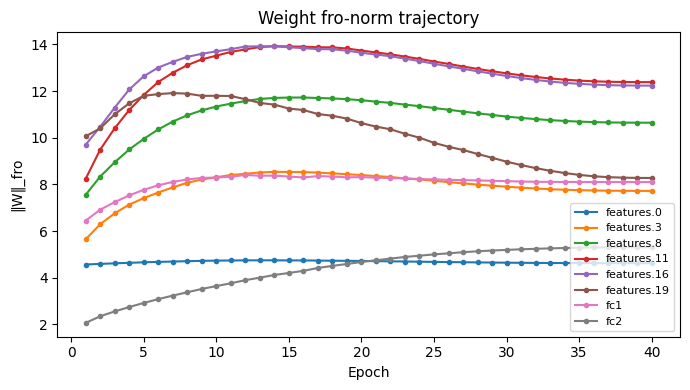

In [20]:
from tanc.visualisation import plot_weight_norm_trajectory
fig = plot_weight_norm_trajectory(view)

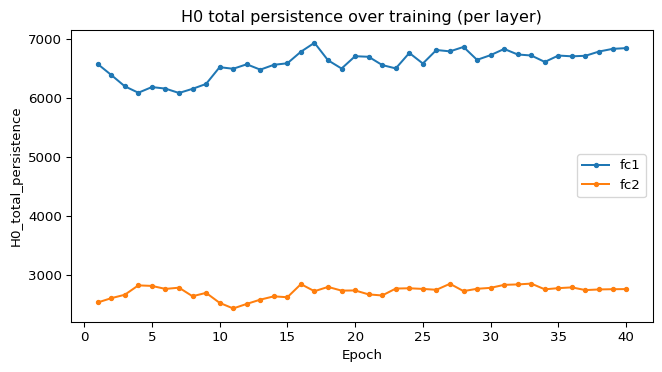

In [ ]:
# A topological quantity evolving over training — the reusable way.
# Configure a pipeline once, then ask for it "over_training": it runs the
# pipeline on every snapshot for you and returns a TrajectorySeries (the numbers
# + a .plot()), replacing the manual per-snapshot .fit() loop.
#
# We track it PER LAYER (one line each) rather than concatenating fc1+fc2 into a
# single graph — the head's two layers have different shapes, so pooling their
# loops muddies the signal. `measures=` also accepts several keys at once (or
# "dimension" / a callable result->float), returning one panel per measure.
series = TDAPipeline.from_paper("watanabe2021").over_training(
    view,
    measures=["H0_total_persistence"],
    layers=["fc1", "fc2"],
    representation="weights",
)
fig = series.plot(title="H0 total persistence over training (per layer)")

# `series` keeps the raw numbers too: series.values[measure][layer], or a tidy
# DataFrame via series.to_frame().

In [22]:
tda.describe_preset("watanabe2021")

watanabe2021 — Watanabe & Yamana (2020)
  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology
  pipeline    : builder='weight_graph'  →  tool='ph'
  input_format: list[weight_matrix]
  default plot: diagram
  expected    : diagram
  key stats   : H1_total_persistence, H1_persistence_entropy
  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a
                flag complex on a similarity matrix.  Relevance R_ij = w_ij /
                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM
                via tool_kwargs__relevance_mode='absolute').  Direct edges,
                induced edges (max 2-hop path product) and triangles (path
                product) each take the integer threshold-index (1..64) of the
                paper's descending relevance schedule as their filtration
                value.  The H1 diagram reproduces the paper's wide 'belt'
                above t

"watanabe2021 — Watanabe & Yamana (2020)\n  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology\n  pipeline    : builder='weight_graph'  →  tool='ph'\n  input_format: list[weight_matrix]\n  default plot: diagram\n  expected    : diagram\n  key stats   : H1_total_persistence, H1_persistence_entropy\n  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a\n                flag complex on a similarity matrix.  Relevance R_ij = w_ij /\n                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM\n                via tool_kwargs__relevance_mode='absolute').  Direct edges,\n                induced edges (max 2-hop path product) and triangles (path\n                product) each take the integer threshold-index (1..64) of the\n                paper's descending relevance schedule as their filtration\n                value.  The H1 diagram reproduces the paper's wide 'belt'\n       

trajectory magnitude dimension : 0.0649
trajectory PH (fractal) dim    : 0.9773


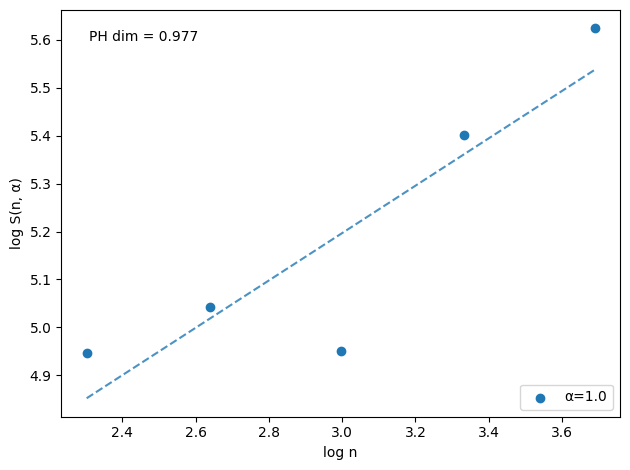

In [23]:
# Two fractal-dimension descriptors of the SAME weight trajectory.
mag = TDAPipeline(builder=None, tool="dimension",
                  tool_kwargs={"estimator": "trajectory_dimension",
                               "method": "magnitude"}).fit(view)
phd = TDAPipeline(builder=None, tool="dimension",
                  tool_kwargs={"estimator": "trajectory_dimension",
                               "method": "ph_euclidean"}).fit(view)
print("trajectory magnitude dimension :", round(mag.dimension_result["magnitude_dimension"], 4))
print("trajectory PH (fractal) dim    :", round(float(phd.dimension), 4))
fig = phd.plot("ph_scaling")

## 7. Applications — pruning, with accuracy before/after

The lenses above are *diagnostic*; `tanc.applications` turns them into
*interventions*. **Pruning** removes weights to shrink a network — the question is always
*which* ones. **PHPM** (Watanabe & Yamana) keeps the weights that carry the head's
strongest topological loops (the persistent H1 features from §5a) and zeroes the rest;
the standard **GMP** baseline simply keeps the largest-magnitude weights. The real test
is whether the *topological* criterion preserves accuracy as well as raw magnitude, so we
prune the trained head both ways at 50% sparsity and measure test accuracy before and
after.

In [24]:
from tanc.topo_tools import compute_watanabe_ph
from tanc.applications import (
    phpm_pruning_mask, gmp_pruning_mask, apply_masks, prune_diagnostics,
)

W_head = snap.weight_matrices(["fc1", "fc2"])     # arrays, (in, out) per layer
ph_head = compute_watanabe_ph(W_head, mode="positive", max_dim=1)

RATIO = 0.5
phpm = phpm_pruning_mask(W_head, ph_head, pruning_ratio=RATIO)
gmp  = gmp_pruning_mask(W_head, pruning_ratio=RATIO, per_layer=True)

@torch.no_grad()
def test_accuracy(m):
    m.eval()
    preds = torch.cat([m(X_te_t[i:i+1000]).argmax(1) for i in range(0, len(X_te_t), 1000)])
    return (preds == y_te_t).float().mean().item()

def load_head(m, W):                # W is [(in,out), (in,out)] → Linear wants (out,in)
    m.fc1.weight.data = torch.as_tensor(np.ascontiguousarray(W[0].T), dtype=torch.float32).to(DEVICE)
    m.fc2.weight.data = torch.as_tensor(np.ascontiguousarray(W[1].T), dtype=torch.float32).to(DEVICE)

model = model.to(DEVICE).eval()     # extraction may have left it on CPU
orig = copy.deepcopy(model.state_dict())
base = test_accuracy(model)
load_head(model, apply_masks(W_head, phpm)); acc_phpm = test_accuracy(model); model.load_state_dict(orig)
load_head(model, apply_masks(W_head, gmp));  acc_gmp  = test_accuracy(model); model.load_state_dict(orig)

print(f"head weights kept: {prune_diagnostics(phpm)['kept']}/{prune_diagnostics(phpm)['total']}"
      f"  (at {int(RATIO*100)}% sparsity)")
print(f"baseline accuracy        : {base:.4f}")
print(f"after PHPM (topological) : {acc_phpm:.4f}   (Δ {acc_phpm-base:+.4f})")
print(f"after GMP  (magnitude)   : {acc_gmp:.4f}   (Δ {acc_gmp-base:+.4f})")

head weights kept: 17024/34048  (at 50% sparsity)
baseline accuracy        : 0.9168
after PHPM (topological) : 0.9081   (Δ -0.0087)
after GMP  (magnitude)   : 0.9108   (Δ -0.0060)


## 8. Shortcuts: the paper-preset gallery

A preset is just **the four choices pre-filled** for a published method. Crucially, a
preset accepts the *same* inputs as a hand-built pipeline — you can apply it to a
**snapshot**, a **trajectory**, or directly to a **model + data**:

```python
TDAPipeline.from_paper("watanabe2021").fit(snap, representation=head_weights)  # snapshot
TDAPipeline.from_paper("andreeva2024").fit(view)                              # trajectory
TDAPipeline.from_paper("ong2026").fit_model(model, X)                         # model + data
```

`list_presets()` is the catalogue; `describe_preset(name)` spells out the four choices a
preset fixes.

In [25]:
TDAPipeline.list_presets()

[ph]
  ballester2024       Ballester et al. (2024)
  gebhart2019         Gebhart et al. (2019)
  karuppiah2025       Karuppiah et al. (2025)
  lacombe2021         Lacombe et al. (2021)
  liu2023             Liu et al. (2023)
  naitzat2020         Naitzat et al. (2020)
  ramamurthy2019      Ramamurthy et al. (2019)
  rieck2019           Rieck et al. (2019)
  watanabe2021        Watanabe & Yamana (2020)

[mapper]
  gabella2021         Gabella (2021)
  gabrielsson2019     Gabrielsson & Carlsson (2019)
  rathore2021         Rathore et al. (2021)
  zhou2023            Zhou et al. (2023)

[dimension]
  andreeva2024        Andreeva et al. (2024)
  birdal2021          Birdal et al. (2021)
  dupuis2023          Dupuis et al. (2023)
  ong2026             Ong et al. (2026)
  ruppik2025          Ruppik et al. (2025)



['andreeva2024',
 'ballester2024',
 'birdal2021',
 'dupuis2023',
 'gabella2021',
 'gabrielsson2019',
 'gebhart2019',
 'karuppiah2025',
 'lacombe2021',
 'liu2023',
 'naitzat2020',
 'ong2026',
 'ramamurthy2019',
 'rathore2021',
 'rieck2019',
 'ruppik2025',
 'watanabe2021',
 'zhou2023']

In [26]:
TDAPipeline.describe_preset("watanabe2021")

watanabe2021 — Watanabe & Yamana (2020)
  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology
  pipeline    : builder='weight_graph'  →  tool='ph'
  input_format: list[weight_matrix]
  default plot: diagram
  expected    : diagram
  key stats   : H1_total_persistence, H1_persistence_entropy
  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a
                flag complex on a similarity matrix.  Relevance R_ij = w_ij /
                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM
                via tool_kwargs__relevance_mode='absolute').  Direct edges,
                induced edges (max 2-hop path product) and triangles (path
                product) each take the integer threshold-index (1..64) of the
                paper's descending relevance schedule as their filtration
                value.  The H1 diagram reproduces the paper's wide 'belt'
                above t

"watanabe2021 — Watanabe & Yamana (2020)\n  description : Watanabe & Yamana (2020) — Topological Measurement / Pruning of Deep Neural Networks Using Persistent Homology\n  pipeline    : builder='weight_graph'  →  tool='ph'\n  input_format: list[weight_matrix]\n  default plot: diagram\n  expected    : diagram\n  key stats   : H1_total_persistence, H1_persistence_entropy\n  notes       : Faithful **directed clique complex** of the FCN (GUDHI), NOT a\n                flag complex on a similarity matrix.  Relevance R_ij = w_ij /\n                Σ_k w_kj (column-normalised; positive part here, |w| for PHPM\n                via tool_kwargs__relevance_mode='absolute').  Direct edges,\n                induced edges (max 2-hop path product) and triangles (path\n                product) each take the integer threshold-index (1..64) of the\n                paper's descending relevance schedule as their filtration\n                value.  The H1 diagram reproduces the paper's wide 'belt'\n       

### Apply the same preset three ways — snapshot, trajectory-model, and model+data

All three entry points are equivalent; use whichever matches what you have in hand.

In [27]:
# (1) on a snapshot we already extracted
r1 = TDAPipeline.from_paper("ong2026").fit(snap, representation="activations")
# (2) on the model + data directly (extraction happens inside)
r2 = TDAPipeline.from_paper("ong2026").fit_model(model, act_X, representation="activations")
print("ong2026 mean ID — fit(snap):", round(float(r1.dimension), 3),
      "| fit_model(model, X):", round(float(r2.dimension), 3))

ong2026 mean ID — fit(snap): 38.444 | fit_model(model, X): 6.322


### A spread of presets on this one model

Each line is a different published method = a different point in the four-axis space,
applied to the same trained network (or its trajectory).

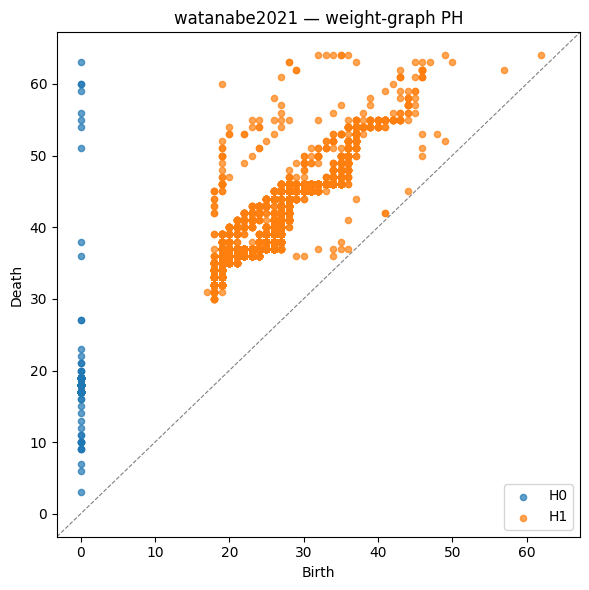

In [28]:
def _fig_title(fig, text):       # avoid suptitle/axes-title overlap
    fig.axes[0].set_title(text); fig.tight_layout()

# weight space → PH (Watanabe directed clique) — pre-filled §5a
res, fig = TDAPipeline.from_paper("watanabe2021").reproduce(snap, representation=head_weights)
_fig_title(fig, "watanabe2021 — weight-graph PH")

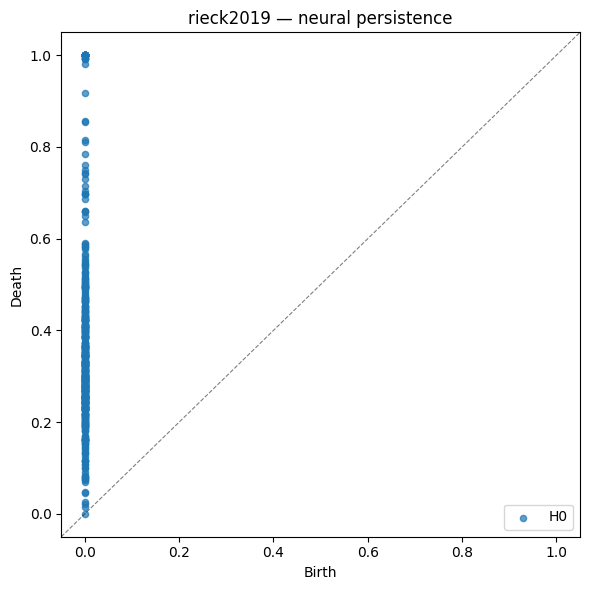

In [29]:
# weight space → PH (Rieck Neural Persistence) on the head
res, fig = TDAPipeline.from_paper("rieck2019").reproduce(snap, representation=head_weights)
_fig_title(fig, "rieck2019 — neural persistence")

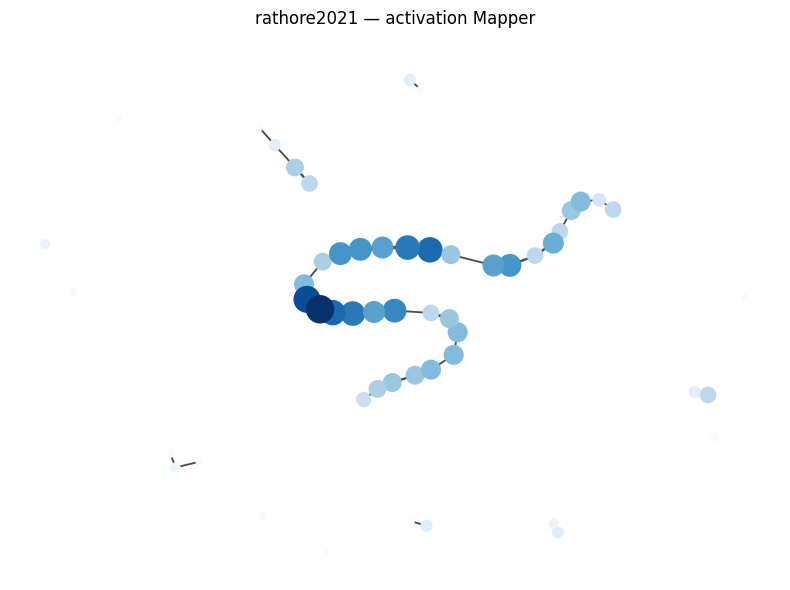

In [30]:
# activation space → Mapper (Rathore / TopoAct)
res, figs = TDAPipeline.from_paper("rathore2021").reproduce(snap, representation="fc1")
fig = figs[0] if isinstance(figs, list) else figs
_fig_title(fig, "rathore2021 — activation Mapper")

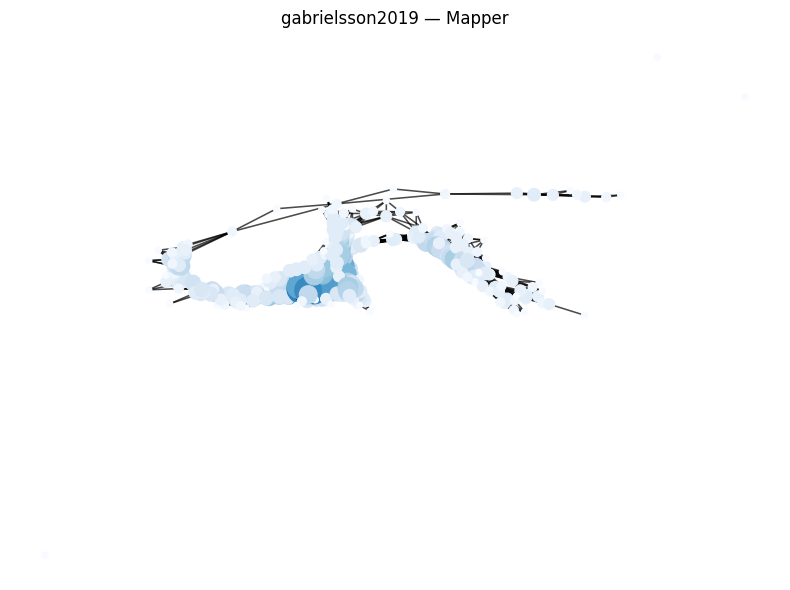

In [31]:
# activation space → Mapper (Gabrielsson & Carlsson)
res, figs = TDAPipeline.from_paper("gabrielsson2019").reproduce(snap, representation="fc1")
fig = figs[0] if isinstance(figs, list) else figs
_fig_title(fig, "gabrielsson2019 — Mapper")

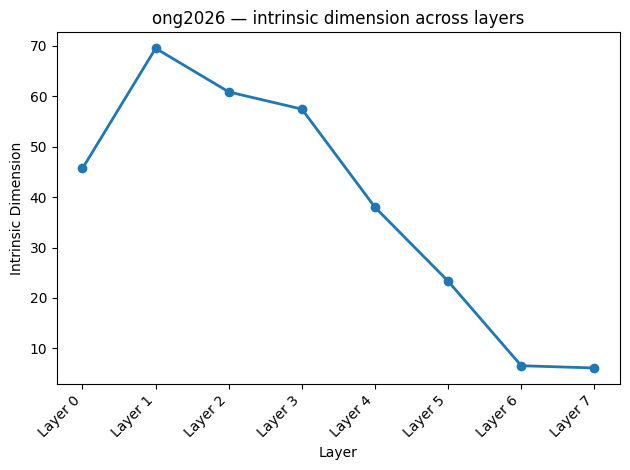

In [32]:
# activation space → intrinsic dimension per layer (Ong)
res, fig = TDAPipeline.from_paper("ong2026").reproduce(snap, representation="activations")
_fig_title(fig, "ong2026 — intrinsic dimension across layers")

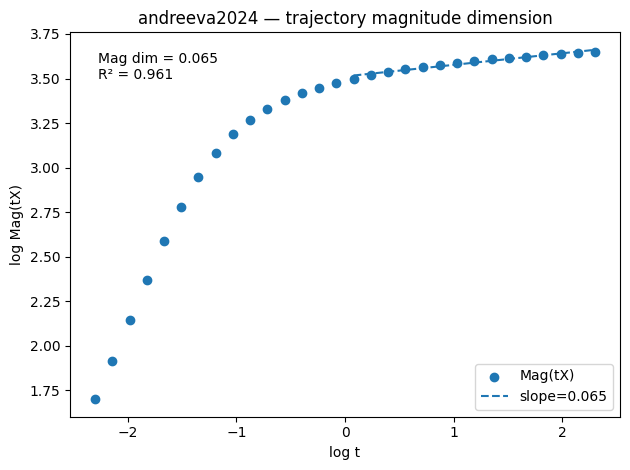

In [33]:
# weight-trajectory → magnitude dimension (Andreeva)
res, fig = TDAPipeline.from_paper("andreeva2024").reproduce(view)
_fig_title(fig, "andreeva2024 — trajectory magnitude dimension")

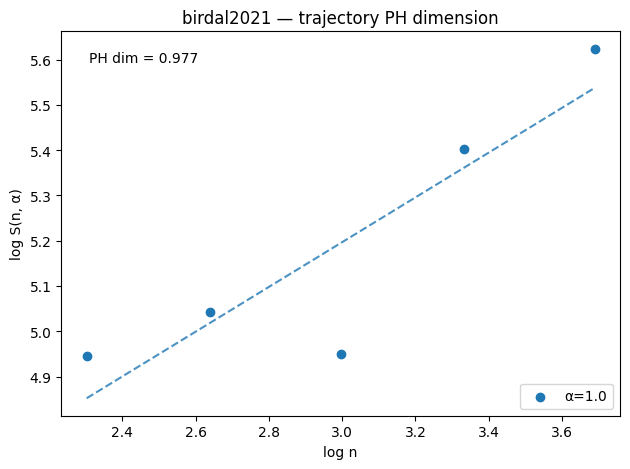

In [34]:
# weight-trajectory → PH (fractal) dimension (Birdal)
res, fig = TDAPipeline.from_paper("birdal2021").reproduce(view)
_fig_title(fig, "birdal2021 — trajectory PH dimension")

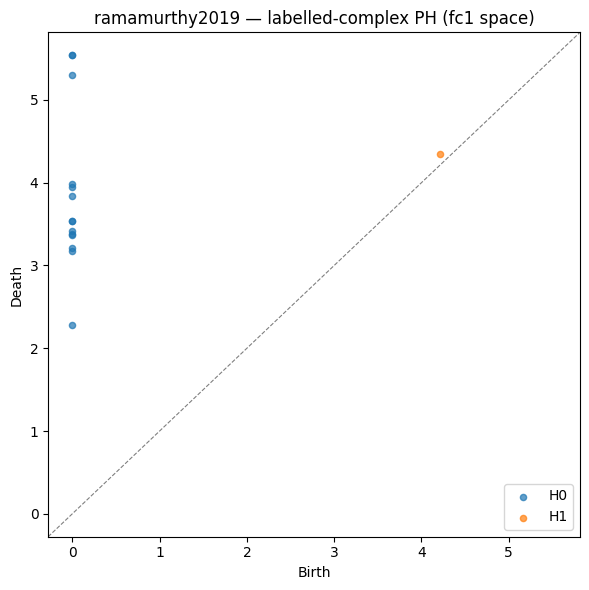

In [35]:
# input + label space → labelled complex PH (Ramamurthy).
# The "points" are a representation layer (fc1 activations, 2-D) coloured by the
# predicted label — not the raw 4-D images.
snap_io = ModelExtractor(model, aspects=["activations", "classifications"],
                         layer_selection="linear_and_conv", device=DEVICE,
                         clarify=False).extract(act_X)
res, fig = TDAPipeline.from_paper("ramamurthy2019").reproduce(
    snap_io, representation=lambda s: (s.activation_matrix("fc1"), s.predicted_labels))
_fig_title(fig, "ramamurthy2019 — labelled-complex PH (fc1 space)")

That is eight published methods — across **weight**, **activation**, **input/label**,
and **trajectory** spaces — each a one-line `from_paper(...)`, all on the same trained
model. Swap any name from `list_presets()` into the same call.

## 9. Saving results & figures

We already cached the trajectory, snapshot, and model in §3. Every result container
persists with `.save()` / `.load()`, and **figures** (including diagrams) save straight
from `.plot(..., save=...)` or `reproduce(..., save=...)`.

reloaded H1 features: 14904
saved: ['head_barcode.pdf', 'head_diagram.png', 'head_ph.tda', 'id_layers.png']


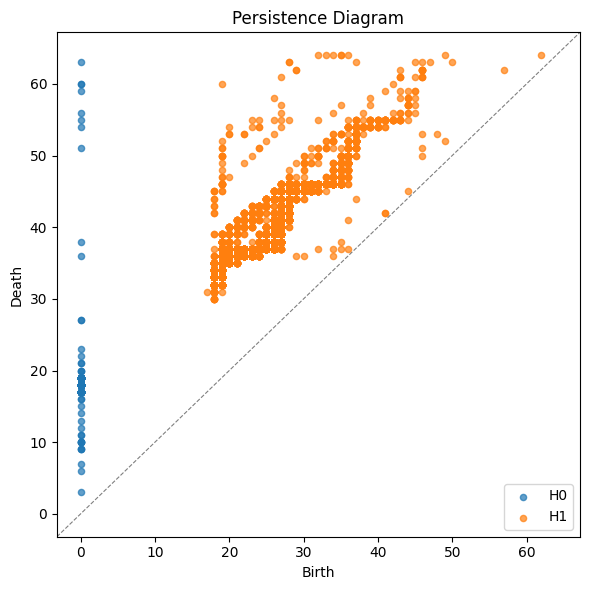

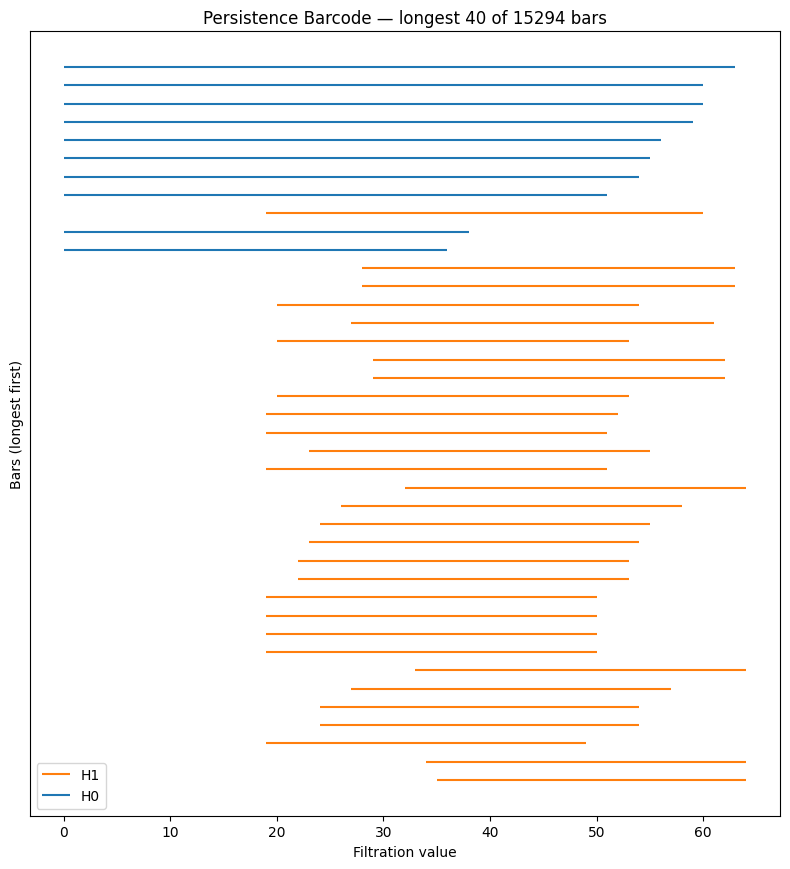

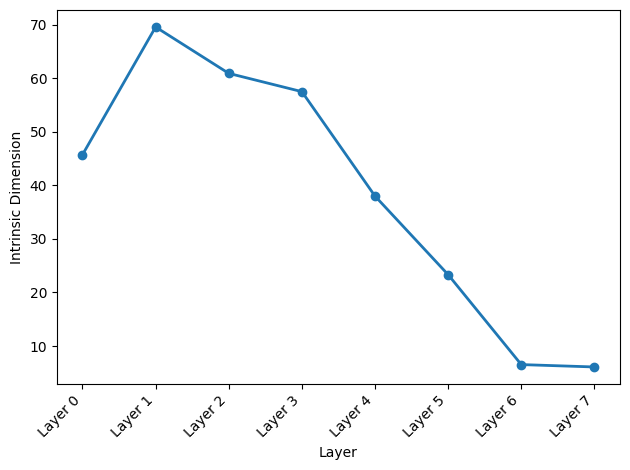

In [36]:
from tanc.topo_tools import TopoResult
OUT = Path("tutorial_outputs"); OUT.mkdir(exist_ok=True)

# Save the computed PH (diagrams + statistics), then reload — no recompute.
res_w.save(OUT / "head_ph.tda")
reloaded = TopoResult.load(OUT / "head_ph.tda")
print("reloaded H1 features:", len(reloaded.diagram(1)))

# Save the diagram figure itself (format from the extension).
reloaded.plot("diagram", save=OUT / "head_diagram.png")
reloaded.plot("barcode", save=OUT / "head_barcode.pdf")

# reproduce() can fit + plot + save in one call:
TDAPipeline.from_paper("ong2026").reproduce(snap, representation="activations",
                                            save=OUT / "id_layers.png")
print("saved:", sorted(p.name for p in OUT.iterdir()))

## Where to go next

- **`tda.help("<topic>")`** — `pipeline`, `graph`, `ph`, `mapper`, `dimension`,
  `extract`, `training`, `save`, `presets`.
- **`TDAPipeline.list_presets()` / `describe_preset(name)`** — the preset shortcuts.
- **`paper_reproduce/` & the docs "recipe gallery"** — one notebook per preset.
- **`GETTING_STARTED.md` / `docs/composing.rst`** — the four-axis mental model.

The whole point: you are **not** limited to the presets. Pick a **space**, a
**construction**, a **method**, and an **output** — and study your network however you
like, in whichever framework you use.